In [6]:
import pandas as pd
import vectorbt as vbt
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals
from ggTrader.Utils import *


In [7]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Walk Forward Optimization

In [8]:
# setup
k = KrakenHistoricalData()
kd = KrakenData()

start_equity = 1000
symbols = [top_kraken[0]]
interval = "4h"
n_trials = 100  # per window
sampler = TPESampler()
optuna.logging.set_verbosity(optuna.logging.WARNING)  # or ERROR / CRITICAL

# Entire time range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Default Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 3,
          'adx_threshold': 0,  # has little affect
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 22,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)

df_multi = k.get_ohlcv_df(symbols, interval=interval)
# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]




Computed test_size=668, max_train_size=2672


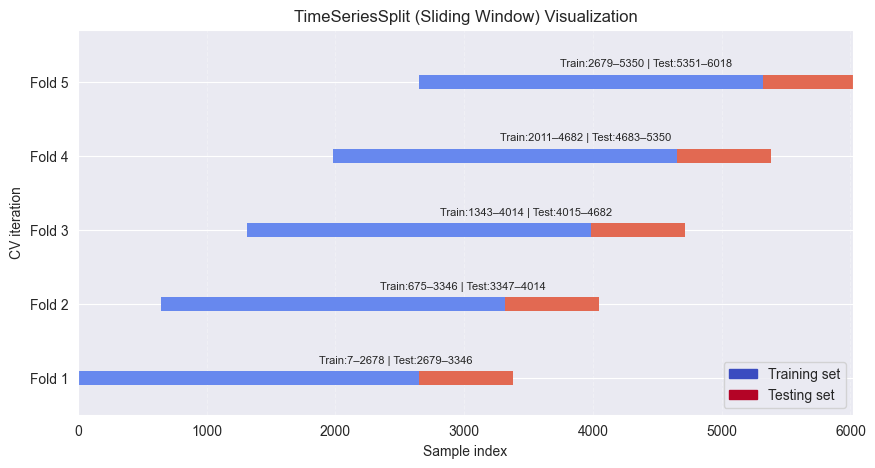

Fold 1: Train [2023-01-02 04:00:00+00:00–2024-03-22 08:00:00+00:00] (445), Test [2024-03-22 12:00:00+00:00–2024-07-11 16:00:00+00:00] (111)
Fold 2: Train [2023-04-23 12:00:00+00:00–2024-07-11 16:00:00+00:00] (445), Test [2024-07-11 20:00:00+00:00–2024-10-31 00:00:00+00:00] (111)
Fold 3: Train [2023-08-12 20:00:00+00:00–2024-10-31 00:00:00+00:00] (445), Test [2024-10-31 04:00:00+00:00–2025-02-19 08:00:00+00:00] (111)
Fold 4: Train [2023-12-02 04:00:00+00:00–2025-02-19 08:00:00+00:00] (445), Test [2025-02-19 12:00:00+00:00–2025-06-10 16:00:00+00:00] (111)
Fold 5: Train [2024-03-22 12:00:00+00:00–2025-06-10 16:00:00+00:00] (445), Test [2025-06-10 20:00:00+00:00–2025-09-30 00:00:00+00:00] (111)


In [9]:
# Train split
n_splits = 5
test_ratio = 0.2
tscv, test_size, max_train_size = make_end_anchored_tscv(n_samples=len(df), n_splits=n_splits, test_ratio=test_ratio)
print(f"Computed test_size={test_size}, max_train_size={max_train_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_indices(tscv, df.index, ax, n_splits)
plt.show()

# 4. Print fold ranges
for i, (tr, tt) in enumerate(tscv.split(df.index), 1):
    print(
        f"Fold {i}: Train [{df.index[tr[0]]}–{df.index[tr[-1]]}] ({len(tr) / 6:.0f}), Test [{df.index[tt[0]]}–{df.index[tt[-1]]}] ({len(tt) / 6:.0f})")

Optuna setup

In [10]:
best_params_list = []
value_list = []

for i, (tr, tt) in enumerate(tscv.split(df.index), 1):
    df_train = df.iloc[tr]
    df_test = df.iloc[tt]
    print(f"{symbols[0]} Fold {i}/{n_splits}:")


    def objective(trial):
        # Entry
        params['adx_threshold'] = trial.suggest_int("adx_threshold", 20, 50)  #
        # params['adx_length'] = trial.suggest_int("adx_length", 2, 50)
        # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.01, 1, step=0.01)
        # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1, step=0.01)

        # Exit
        params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.1)
        # params['atr_length'] = trial.suggest_int("atr_length", 2, 50)
        params['ce_low_length'] = trial.suggest_int("ce_low_length", 2, 100)
        # params['ce_high_length'] = trial.suggest_int("ce_high_length", 2, 200, step=2)

        s = Signals(**params)

        signals = s.calc_signals(df_train.copy())
        close = signals['close']
        entries = signals['entry_signal']
        exits = signals['exit_signal']
        # Build target allocation:
        # 1.0 = 100% of portfolio in asset
        # 0.0 = 100% in cash
        size = pd.Series(np.nan, index=close.index)
        size[entries] = 1.0   # on buy signal: go all-in
        size[exits] = 0.0     # on sell signal: go flat

        pf = vbt.Portfolio.from_orders(
            close=close,
            size=size,
            size_type='targetpercent',  # interpret `size` as target weight
            direction='longonly',
            init_cash=start_equity,           # starting cash
            fees=transaction_fee,                 # 0.1% fee (optional)
            slippage=0.0005,            # optional
        )
        stats = pf.stats()
        sharpe = stats['Sharpe Ratio']
        if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
            raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
        return sharpe


    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params
    best_params_list.append(best_params)

    # backtest best parameters on test set
    for param in best_params.keys():
        params[param] = best_params[param]

    s = Signals(**params)

    signals = s.calc_signals(df_train.copy())
    close = signals['close']
    entries = signals['entry_signal']
    exits = signals['exit_signal']
    # Build target allocation:
    # 1.0 = 100% of portfolio in asset
    # 0.0 = 100% in cash
    size = pd.Series(np.nan, index=close.index)
    size[entries] = 1.0   # on buy signal: go all-in
    size[exits] = 0.0     # on sell signal: go flat

    pf = vbt.Portfolio.from_orders(
        close=close,
        size=size,
        size_type='targetpercent',  # interpret `size` as target weight
        direction='longonly',
        init_cash=start_equity,           # starting cash
        fees=transaction_fee,                 # 0.1% fee (optional)
        slippage=0.0005,            # optional
    )
    stats = pf.stats()
    sharpe = stats['Sharpe Ratio']
    # sortino = stats['Sortino Ratio']
    value_list.append(sharpe)

print(f"...Optimization Complete")

BTC Fold 1/5:
BTC Fold 2/5:
BTC Fold 3/5:
BTC Fold 4/5:
BTC Fold 5/5:
...Optimization Complete


In [11]:
print("\nWalk Forward Optimization Results:")
rows = [{**p, "score": float(s), "fold": i + 1} for i, (p, s) in enumerate(zip(best_params_list, value_list))]
df_result = pd.DataFrame(rows).set_index("fold")
print(tabulate(df_result, headers="keys", tablefmt="github"))
result_stats = df_result.describe()

print("\nWalk Forward Optimization Stats:")
print(tabulate(result_stats, headers="keys", tablefmt="github"))

avg = df_result.mean(numeric_only=True)  # returns a Series with column averages

params['atr_multiplier'] = round(avg['atr_multiplier'], 1)
params['ce_low_length'] = int(avg['ce_low_length'])
params['adx_threshold'] = int(avg['adx_threshold'])



Walk Forward Optimization Results:
|   fold |   adx_threshold |   atr_multiplier |   ce_low_length |   score |
|--------|-----------------|------------------|-----------------|---------|
|      1 |              34 |              4.2 |              30 | 3.08286 |
|      2 |              38 |              7   |              44 | 2.29383 |
|      3 |              38 |              7   |              30 | 2.23472 |
|      4 |              46 |              4.9 |              74 | 2.09259 |
|      5 |              44 |              7.2 |              42 | 1.34848 |

Walk Forward Optimization Stats:
|       |   adx_threshold |   atr_multiplier |   ce_low_length |    score |
|-------|-----------------|------------------|-----------------|----------|
| count |         5       |          5       |               5 | 5        |
| mean  |        40       |          6.06    |              44 | 2.2105   |
| std   |         4.89898 |          1.40285 |              18 | 0.617561 |
| min   |        3

Run final backtest with average parameters

In [12]:
for param in best_params.keys():
    params[param] = best_params[param]

s = Signals(**params)

signals = s.calc_signals(df.copy())
close = signals['close']
entries = signals['entry_signal']
exits = signals['exit_signal']
# Build target allocation:
# 1.0 = 100% of portfolio in asset
# 0.0 = 100% in cash
size = pd.Series(np.nan, index=close.index)
size[entries] = 1.0   # on buy signal: go all-in
size[exits] = 0.0     # on sell signal: go flat

pf = vbt.Portfolio.from_orders(
    close=close,
    size=size,
    size_type='targetpercent',  # interpret `size` as target weight
    direction='longonly',
    init_cash=start_equity,           # starting cash
    fees=transaction_fee,                 # 0.1% fee (optional)
    slippage=0.0005,            # optional
)
stats = pf.stats()
print(stats)

Start                         2023-01-01 00:00:00+00:00
End                           2025-09-30 00:00:00+00:00
Period                               1003 days 04:00:00
Start Value                                      1000.0
End Value                                   3298.738275
Total Return [%]                             229.873827
Benchmark Return [%]                         592.708492
Max Gross Exposure [%]                            100.0
Total Fees Paid                              121.701387
Max Drawdown [%]                              32.758752
Max Drawdown Duration                 280 days 00:00:00
Total Trades                                         10
Total Closed Trades                                   9
Total Open Trades                                     1
Open Trade PnL                               -12.375629
Win Rate [%]                                  77.777778
Best Trade [%]                                49.723244
Worst Trade [%]                              -18

In [13]:
pf.plot(width=1600, height=1500).show()

In [14]:
# # Python
# from pathlib import Path
# import pandas as pd
#
# def load_or_create_csv(path, columns=None):
#     p = Path(path)
#     if p.exists():
#         return pd.read_csv(p,index_col=0)
#     # create empty DataFrame with optional columns
#     return pd.DataFrame(columns=columns or [])
#
# filename = "optimization_results.csv"
# df_stats_csv = load_or_create_csv(filename)
# print(df_stats_csv)
# df_stats_csv  = pd.concat([df_stats_csv, df_stats], ignore_index=False)
# print(df_stats_csv)
# df_stats_csv.to_csv(filename)

Test on latest result for the last 3 months

In [16]:
kd = KrakenData()

df_latest = kd.fetch_ohlcv_df(kd.kraken, symbols[0], timeframe='4h', limit=700)

s = Signals(**params)

signals = s.calc_signals(df_latest.copy())
close = signals['close']
entries = signals['entry_signal']
exits = signals['exit_signal']
# Build target allocation:
# 1.0 = 100% of portfolio in asset
# 0.0 = 100% in cash
size = pd.Series(np.nan, index=close.index)
size[entries] = 1.0   # on buy signal: go all-in
size[exits] = 0.0     # on sell signal: go flat

pf = vbt.Portfolio.from_orders(
    close=close,
    size=size,
    size_type='targetpercent',  # interpret `size` as target weight
    direction='longonly',
    init_cash=start_equity,           # starting cash
    fees=transaction_fee,                 # 0.1% fee (optional)
    slippage=0.0005,            # optional
)

stats = pf.stats()
print(stats)

Start                         2025-07-14 16:00:00+00:00
End                           2025-11-08 04:00:00+00:00
Period                                116 days 16:00:00
Start Value                                      1000.0
End Value                                    980.120412
Total Return [%]                              -1.987959
Benchmark Return [%]                         -14.628857
Max Gross Exposure [%]                            100.0
Total Fees Paid                                6.435249
Max Drawdown [%]                              10.261831
Max Drawdown Duration                  32 days 12:00:00
Total Trades                                          1
Total Closed Trades                                   1
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                        0.0
Best Trade [%]                                 -1.99442
Worst Trade [%]                                -

In [17]:
pf.plot(width=1600, height=1500).show()